In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.saving import register_keras_serializable
from keras.models import load_model
from sklearn.model_selection import train_test_split
from matplotlib.colors import BoundaryNorm

# -----------------------
# Load data
# -----------------------
df_full = pd.read_csv("HQ_Data_Clean_new.csv")   # contains subject_sp_id + features
age_df  = pd.read_csv("rbsr-new.csv")            # contains subject_sp_id + age_at_eval_years

if "subject_sp_id" not in df_full.columns:
    raise ValueError("HQ_Data_Clean_new.csv must contain 'subject_sp_id'")
if not {"subject_sp_id", "age_at_eval_years"}.issubset(age_df.columns):
    raise ValueError("rbsr-new.csv must contain 'subject_sp_id' and 'age_at_eval_years'")

# -----------------------
# Align ages to df_full row order (critical)
# -----------------------
age_map = age_df[["subject_sp_id", "age_at_eval_years"]].drop_duplicates("subject_sp_id")
ages_all = (
    df_full[["subject_sp_id"]]
    .merge(age_map, on="subject_sp_id", how="left")["age_at_eval_years"]
    .to_numpy()
)

sex_map = age_df[["subject_sp_id", "sex"]].drop_duplicates("subject_sp_id")
sex_all = (
    df_full[["subject_sp_id"]]
    .merge(sex_map, on="subject_sp_id", how="left")["sex"]
    .to_numpy()
)

# Feature matrix (drop ID after alignment)
df = df_full.drop(columns=["subject_sp_id"])

# -----------------------
# Sampling layer (for loading models)
# -----------------------
@register_keras_serializable()
class Sampling(keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        eps = tf.random.normal(tf.shape(z_mean))
        return z_mean + tf.exp(0.5 * z_log_var) * eps

encoding_size = 4

# -----------------------
# Train/val split (keep indices!)
# -----------------------
idx = np.arange(len(df))
train_data, val_data, idx_train, idx_val = train_test_split(
    df, idx, test_size=0.2, random_state=42
)

# Validation ages aligned by idx_val
ages_val = ages_all[idx_val]

# -----------------------
# Build discrete color indices for validation (length must equal len(idx_val))
# -----------------------
unique_vals = np.sort(pd.unique(pd.Series(ages_val).dropna()))
val_to_idx = {v: i for i, v in enumerate(unique_vals)}

# map ages -> indices, set missing ages to -1
color_idx_val = np.array([val_to_idx.get(v, -1) for v in ages_val], dtype=int)

# colormap + norm for the discrete indices 0..N-1
cmap = plt.cm.get_cmap("viridis_r", len(unique_vals))
norm = BoundaryNorm(np.arange(len(unique_vals) + 1) - 0.5, cmap.N)

C:\Users\B00804975\AppData\Local\Temp\ipykernel_31236\3496780982.py:75: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("viridis_r", len(unique_vals))


In [2]:
from sklearn.model_selection import train_test_split
train_data, val_data = train_test_split(df, test_size=0.2, random_state=42)

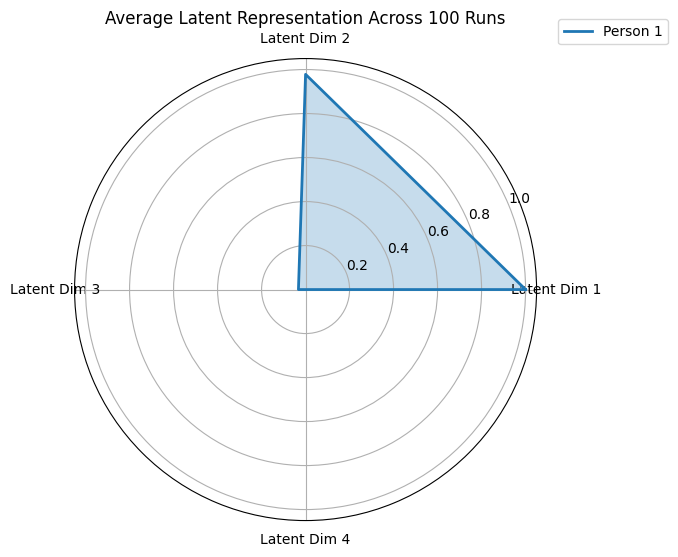

In [3]:
person_index = 0
data_point = df.iloc[person_index].values.reshape(1, -1)  # shape (1, D)

all_latents = []

# Loop through saved encoders
num_runs = 100
for run in range(num_runs):
    encoder_path = f"saved_models/encoder_run{run+1}.h5"
    encoder = load_model(
        encoder_path,
        custom_objects={"Sampling": Sampling},  # critical for VAE encoder
        compile=False
    )
    
    z_mean, _, _ = encoder.predict(data_point, verbose=0)  # shape (1, latent_dim)
    all_latents.append(z_mean[0])  # extract row

# Average across runs
avg_latent_point = np.mean(all_latents, axis=0)

# Normalize to [0,1] for radar plot
avg_latent_point = (avg_latent_point - avg_latent_point.min()) / (avg_latent_point.max() - avg_latent_point.min())

# Radar chart values
values = avg_latent_point.tolist()
values += values[:1]  # close loop

angles = np.linspace(0, 2 * np.pi, len(avg_latent_point), endpoint=False).tolist()
angles += angles[:1]

# Plot radar chart
fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(polar=True))
ax.plot(angles, values, label=f"Person {person_index+1}", linewidth=2, linestyle='solid')
ax.fill(angles, values, alpha=0.25)

# Labels & Styling
ax.set_xticks(angles[:-1])
ax.set_xticklabels([f"Latent Dim {i+1}" for i in range(len(avg_latent_point))])
ax.set_title("Average Latent Representation Across 100 Runs")
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.savefig("radar_500.png", dpi=600, bbox_inches="tight")

plt.show()

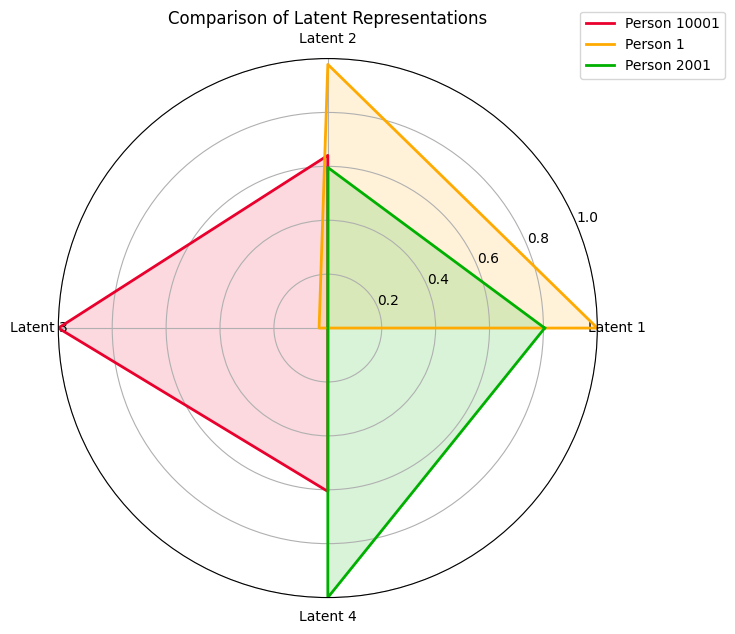

In [4]:
# People to compare
person_indices = [10000, 0, 2000]

all_people_latents = []

# Load each person's average latent representation
for person_index in person_indices:
    data_point = df.iloc[person_index].values.reshape(1, -1)

    all_latents = []

    for run in range(100):
        encoder_path = f"saved_models/encoder_run{run+1}.h5"

        encoder = load_model(
            encoder_path,
            custom_objects={"Sampling": Sampling},
            compile=False
        )

        z_mean, _, _ = encoder.predict(data_point, verbose=0)
        all_latents.append(z_mean[0])

    avg_latent = np.mean(all_latents, axis=0)

    # Normalize this person only
    avg_latent_norm = (avg_latent - avg_latent.min()) / (
        avg_latent.max() - avg_latent.min()
    )

    all_people_latents.append(avg_latent_norm)

all_people_latents = np.array(all_people_latents)

# Radar chart setup
angles = np.linspace(
    0,
    2 * np.pi,
    all_people_latents.shape[1],
    endpoint=False
).tolist()
angles += angles[:1]

colours = ["#e9002d", "#ffaa00", "#00b000"]

# Combined radar plot
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for i, latent in enumerate(all_people_latents):
    values = latent.tolist()
    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        color=colours[i],
        label=f"Person {person_indices[i]+1}"
    )

    ax.fill(
        angles,
        values,
        alpha=0.15,
        color=colours[i]
    )

ax.set_xticks(angles[:-1])
ax.set_xticklabels(
    [f"Latent {i+1}" for i in range(all_people_latents.shape[1])]
)

ax.set_ylim(0, 1)

ax.set_title("Comparison of Latent Representations")
ax.legend(loc="upper right", bbox_to_anchor=(1.25, 1.1))

plt.savefig("three_person_radar.png", dpi=600, bbox_inches="tight")
plt.show()

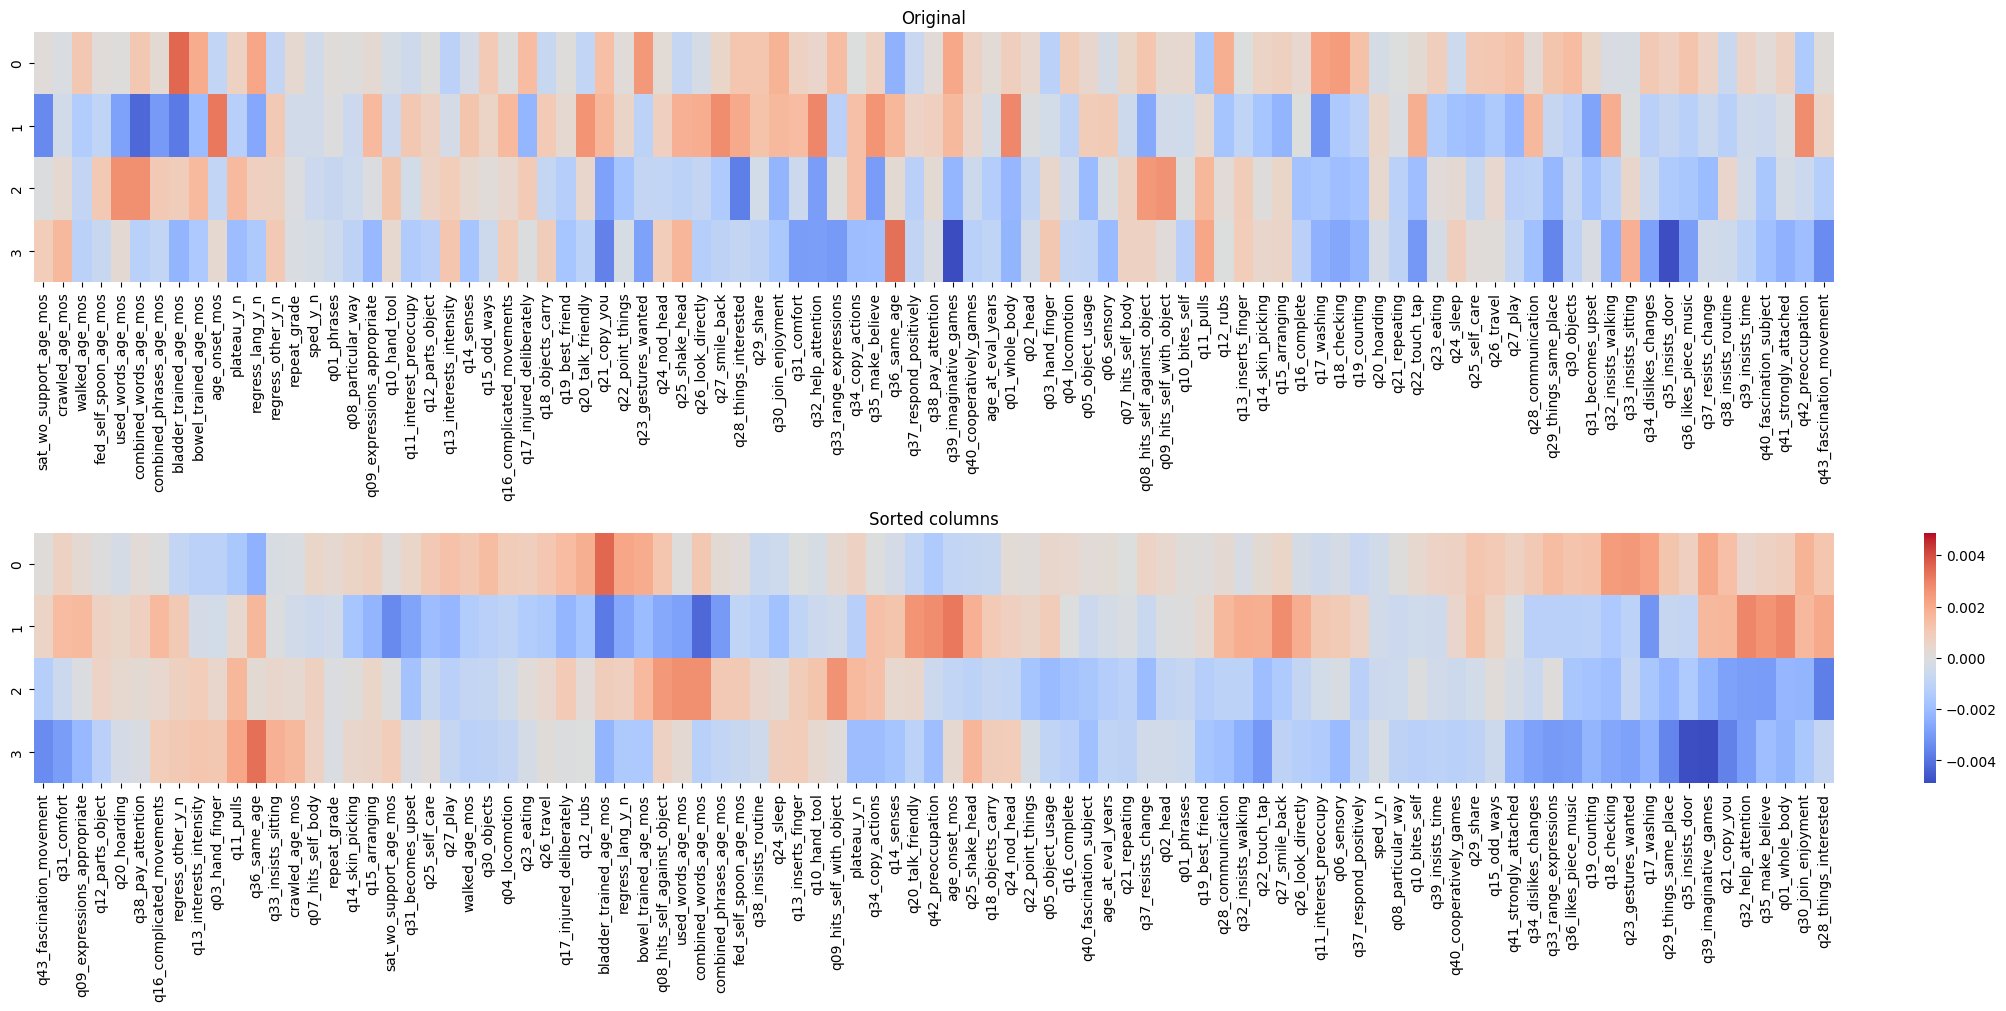

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import pdist, squareform
import pandas as pd
import seaborn as sns
import networkx as nx

# Load CSV fully
hm = pd.read_csv("avg_100_VAE_Heatmap.csv")

# Drop the first column if it's just an index
hm = hm.drop(hm.columns[0], axis=1)

# Convert to NumPy
X = hm.values

# 1) Standardize rows
X_std = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-8)

# 2) Distance matrix
dist_matrix = squareform(pdist(X_std.T, metric="euclidean"))

# 3) Solve TSP for column ordering
G = nx.from_numpy_array(dist_matrix)
path = nx.approximation.traveling_salesman_problem(G, cycle=False, weight="weight")

# Reorder columns by path
X_sorted = X[:, path]
hm_sorted = hm.iloc[:, path]  # keep names aligned

# --- Plot ---
vmax = np.max(np.abs(X))
vmin = -vmax

fig, axes = plt.subplots(2, 1, figsize=(20, 10), constrained_layout=True)

# Original heatmap with true feature names
sns.heatmap(hm, cmap="coolwarm", vmin=vmin, vmax=vmax, ax=axes[0], cbar=False)
axes[0].set_title("Original")

# Sorted heatmap with reordered names
sns.heatmap(hm_sorted, cmap="coolwarm", vmin=vmin, vmax=vmax, ax=axes[1], cbar=True)
axes[1].set_title("Sorted columns")

plt.savefig("sorted_heatmap.png", dpi=300)
plt.show()

In [6]:
num_runs = 100
x = df.to_numpy(dtype=np.float32)  # (N, D)

z_means_runs = []

for run in range(num_runs):
    encoder_path = f"saved_models/encoder_run{run+1}.h5"
    enc = load_model(encoder_path, custom_objects={"Sampling": Sampling}, compile=False)

    # encoder outputs: (z_mean, z_log_var, z) in your setup
    z_mean, z_log_var, z = enc.predict(x, verbose=0)  # z_mean: (N, K)
    z_means_runs.append(z_mean)

z_means_runs = np.stack(z_means_runs, axis=0)   # (R, N, K)
z_mean_avg = z_means_runs.mean(axis=0)          # (N, K)

latent_df_avg = pd.DataFrame(
    z_mean_avg,
    columns=[f"z{i}" for i in range(z_mean_avg.shape[1])]
)

C:\Users\B00804975\AppData\Local\Temp\ipykernel_23092\2035010658.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = plt.cm.get_cmap("viridis_r", len(unique_vals))


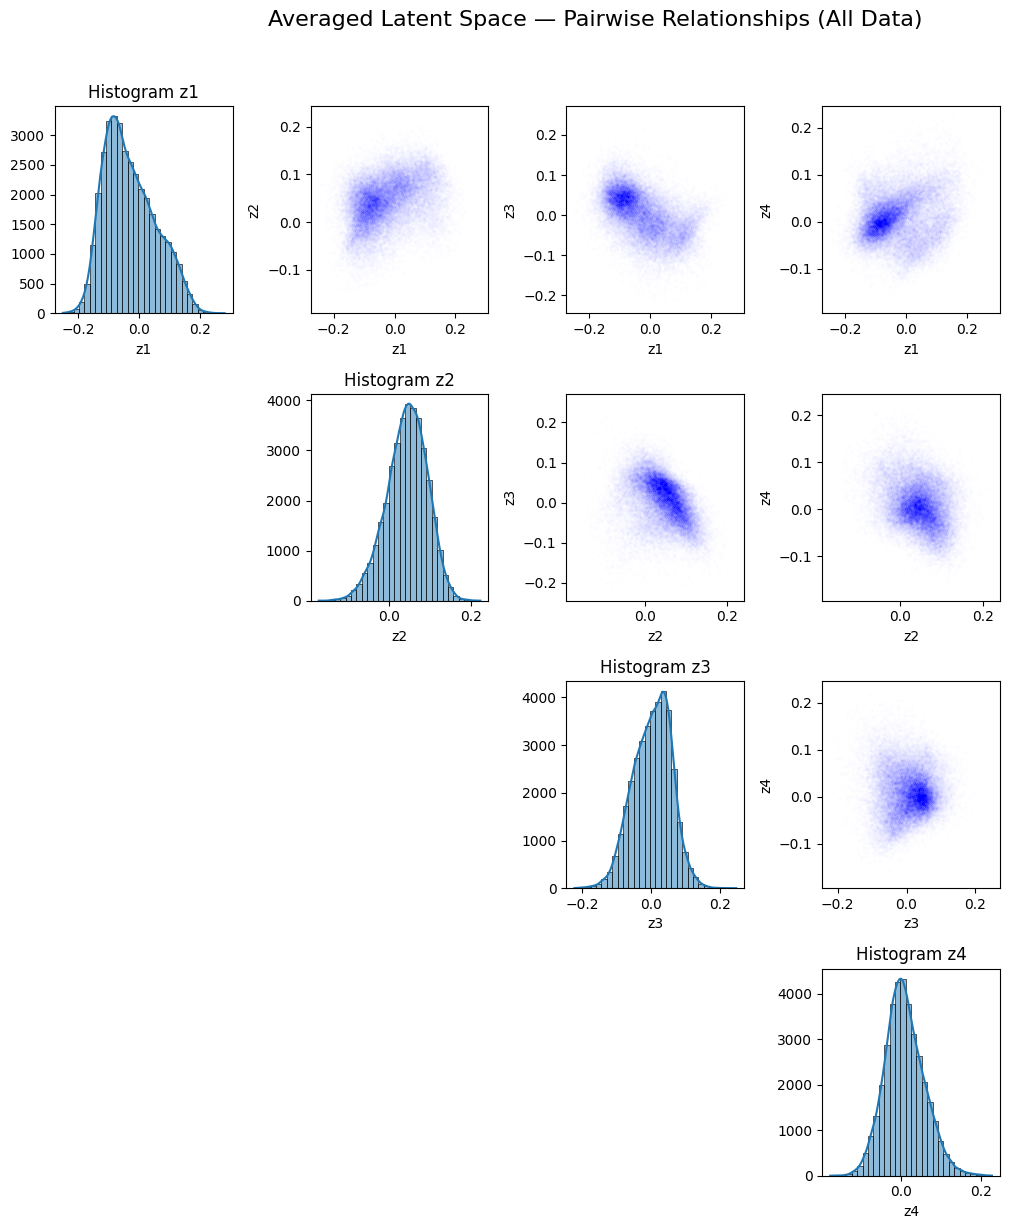

In [7]:
import seaborn as sns

# ---- Build colors for ALL rows ----
values = ages_all

unique_vals = np.sort(pd.unique(pd.Series(values).dropna()))
val_to_idx = {v: i for i, v in enumerate(unique_vals)}

color_idx_all = np.array([val_to_idx.get(v, -1) for v in values], dtype=int)

cmap = plt.cm.get_cmap("viridis_r", len(unique_vals))
norm = BoundaryNorm(np.arange(len(unique_vals)+1)-0.5, cmap.N)

# ---- Mask missing ages ----
mask = color_idx_all >= 0

latent_plot = latent_df_avg.loc[mask].reset_index(drop=True)
color_plot = color_idx_all[mask]

K = latent_plot.shape[1]

fig, axes = plt.subplots(K, K, figsize=(3*K, 3*K), squeeze=False)

for i in range(K):
    for j in range(K):
        ax = axes[i, j]

        if j < i:
            ax.axis("off")
            continue

        if i == j:
            sns.histplot(latent_plot.iloc[:, i], bins=30, kde=True, ax=ax)
            ax.set_ylabel("")
            ax.set_xlabel(f"z{i+1}")
            ax.set_title(f"Histogram z{i+1}")

        else:
            ax.scatter(
                latent_plot.iloc[:, i],
                latent_plot.iloc[:, j],
                color="blue",
                #c=color_plot,
                #cmap=cmap,
                #norm=norm,
                alpha=0.005,
                s=3
            )
           # pair = (f"z{i+1}", f"z{j+1}")
           #if pair in best_lookup:
              #  direction = best_lookup[pair]

               # if abs(direction[0]) < 1e-10:
                  #  ax.axvline(0, color="red", linewidth=2)
                #else:
                    #slope = direction[1] / direction[0]
                    #x_vals = np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], 200)
                    #y_vals = slope * x_vals
                    #ax.plot(x_vals, y_vals, color="red", linewidth=2)
                    

            ax.set_xlabel(f"z{i+1}")
            ax.set_ylabel(f"z{j+1}")

# ---- Legend ----
N = len(unique_vals)

handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        linestyle="",
        markerfacecolor=cmap(i/(N-1) if N > 1 else 0.5),
        markeredgecolor="none",
        markersize=6,
        label=str(v)
    )
    for i, v in enumerate(unique_vals)
]

#fig.legend(handles=handles, title="Age", loc="center left", bbox_to_anchor=(0.85,0.5))

fig.suptitle("Averaged Latent Space — Pairwise Relationships (All Data)", y=1.02, fontsize=16)
fig.tight_layout(rect=[0,0,0.85,1])

fig.savefig("Fig_6.png", dpi=600, bbox_inches="tight")

plt.show()

In [8]:
all_recon_errors = []
num_runs = 100

# Data tensor
x = train_data.values.astype(np.float32)  # use numpy array for MSE
x_tensor = tf.convert_to_tensor(x)

for run in range(num_runs):
    print(f"=== Run {run+1}/{num_runs} ===")

    encoder_path = f"saved_models/encoder_run{run+1}.h5"
    decoder_path = f"saved_models/decoder_run{run+1}.h5"

    # Load encoder & decoder
    encoder = load_model(
        encoder_path,
        custom_objects={"Sampling": Sampling},
        compile=False
    )
    decoder = load_model(decoder_path, compile=False)

    # Encode & decode
    z_mean, _, _ = encoder.predict(x, verbose=0)    # latent means
    x_recon = decoder.predict(z_mean, verbose=0)    # reconstruction

    # Compute reconstruction error (MSE)
    mse = np.mean((x - x_recon) ** 2)
    print(f"  Reconstruction MSE: {mse:.6f}")
    all_recon_errors.append(mse)

=== Run 1/100 ===
  Reconstruction MSE: 0.143462
=== Run 2/100 ===
  Reconstruction MSE: 0.149349
=== Run 3/100 ===
  Reconstruction MSE: 0.145045
=== Run 4/100 ===
  Reconstruction MSE: 0.146766
=== Run 5/100 ===
  Reconstruction MSE: 0.150269
=== Run 6/100 ===
  Reconstruction MSE: 0.146956
=== Run 7/100 ===
  Reconstruction MSE: 0.143056
=== Run 8/100 ===
  Reconstruction MSE: 0.149211
=== Run 9/100 ===
  Reconstruction MSE: 0.145940
=== Run 10/100 ===
  Reconstruction MSE: 0.147298
=== Run 11/100 ===
  Reconstruction MSE: 0.149294
=== Run 12/100 ===
  Reconstruction MSE: 0.152396
=== Run 13/100 ===
  Reconstruction MSE: 0.149684
=== Run 14/100 ===
  Reconstruction MSE: 0.143802
=== Run 15/100 ===
  Reconstruction MSE: 0.146129
=== Run 16/100 ===
  Reconstruction MSE: 0.144353
=== Run 17/100 ===
  Reconstruction MSE: 0.144464
=== Run 18/100 ===
  Reconstruction MSE: 0.144271
=== Run 19/100 ===
  Reconstruction MSE: 0.147990
=== Run 20/100 ===
  Reconstruction MSE: 0.144440
=== Run 2

In [9]:
# ----- Summary -----
print("\n=== Reconstruction Error Summary Across 100 Runs ===")
print(f"Mean MSE: {np.mean(all_recon_errors):.6f}")
print(f"Std  MSE: {np.std(all_recon_errors):.6f}")
print(f"Min  MSE: {np.min(all_recon_errors):.6f}")
print(f"Max  MSE: {np.max(all_recon_errors):.6f}")


=== Reconstruction Error Summary Across 100 Runs ===
Mean MSE: 0.147105
Std  MSE: 0.004014
Min  MSE: 0.141112
Max  MSE: 0.175647


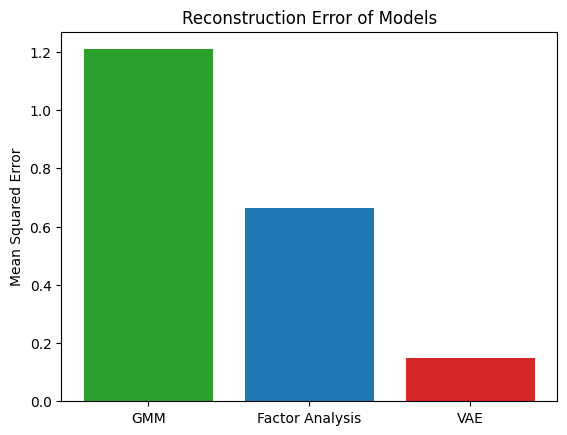

In [10]:
fig, ax = plt.subplots()

models = ['GMM', 'Factor Analysis', 'VAE']
counts = [1.2085, 0.6641, 0.147081]
bar_colors = ['tab:green', 'tab:blue', 'tab:red']

ax.bar(models, counts, color=bar_colors)

ax.set_ylabel('Mean Squared Error')
ax.set_title('Reconstruction Error of Models')

plt.savefig("MSE_Models.svg", format="svg", dpi=300)

plt.show()

In [11]:
latent_df_avg.to_csv('4D_representation.csv', index=False) 

In [12]:
import numpy as np

consistancy_df = np.array([
    [0.90,0.90,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],
    [0.63,0.83,0.71,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],
    [0.49,0.78,0.73,0.66,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],
    [0.52,0.67,0.49,0.77,0.82,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],
    [0.80,0.69,0.53,0.56,0.15,0.86,np.nan,np.nan,np.nan,np.nan,np.nan,np.nan],
    [0.66,0.40,0.74,0.39,0.56,0.73,0.32,np.nan,np.nan,np.nan,np.nan,np.nan],
    [0.47,0.28,0.50,0.12,0.18,0.33,0.49,0.50,np.nan,np.nan,np.nan,np.nan],
    [0.71,0.32,0.33,0.75,0.62,0.56,0.14,0.35,0.46,np.nan,np.nan,np.nan],
    [0.19,0.43,0.56,0.41,0.34,0.62,0.66,0.16,0.37,0.76,np.nan,np.nan],
    [0.43,0.42,0.13,0.40,0.68,0.76,0.78,0.16,0.17,0.39,0.36,np.nan],
    [0.67,0.68,0.23,0.31,0.41,0.55,0.82,0.20,0.10,0.46,0.48,0.46]
])

# Sort each row in descending order, keeping NaNs at the end
sorted_df = np.array([np.sort(row[~np.isnan(row)])[::-1] for row in consistancy_df], dtype=object)

# Pad with NaNs to make all rows same length again
max_len = consistancy_df.shape[1]
sorted_df = np.array([np.concatenate([r, np.full(max_len - len(r), np.nan)]) for r in sorted_df])

print(sorted_df)

[[0.9  0.9   nan  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [0.83 0.71 0.63  nan  nan  nan  nan  nan  nan  nan  nan  nan]
 [0.78 0.73 0.66 0.49  nan  nan  nan  nan  nan  nan  nan  nan]
 [0.82 0.77 0.67 0.52 0.49  nan  nan  nan  nan  nan  nan  nan]
 [0.86 0.8  0.69 0.56 0.53 0.15  nan  nan  nan  nan  nan  nan]
 [0.74 0.73 0.66 0.56 0.4  0.39 0.32  nan  nan  nan  nan  nan]
 [0.5  0.5  0.49 0.47 0.33 0.28 0.18 0.12  nan  nan  nan  nan]
 [0.75 0.71 0.62 0.56 0.46 0.35 0.33 0.32 0.14  nan  nan  nan]
 [0.76 0.66 0.62 0.56 0.43 0.41 0.37 0.34 0.19 0.16  nan  nan]
 [0.78 0.76 0.68 0.43 0.42 0.4  0.39 0.36 0.17 0.16 0.13  nan]
 [0.82 0.68 0.67 0.55 0.48 0.46 0.46 0.41 0.31 0.23 0.2  0.1 ]]


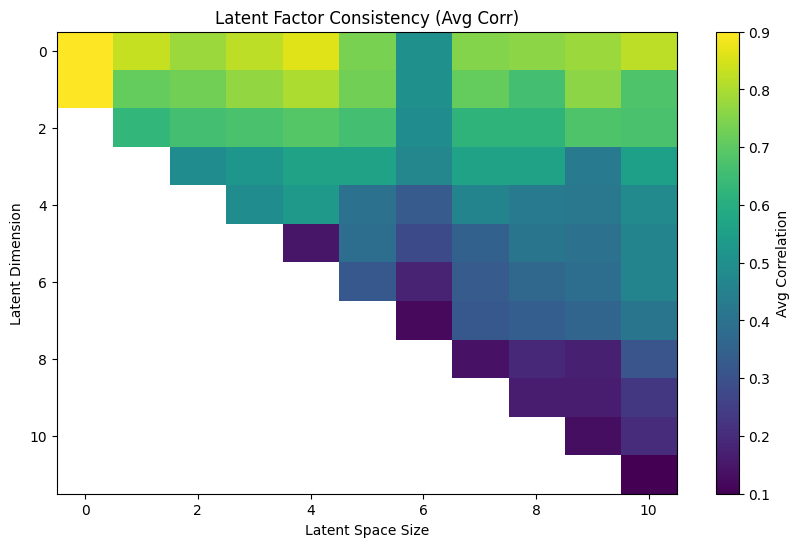

In [13]:
plt.figure(figsize=(10, 6))

im = plt.imshow(
    sorted_df.T,          # transpose
    aspect='auto',
    origin='upper'   # match matrix-style orientation
)


plt.colorbar(im, label='Avg Correlation')

plt.xlabel('Latent Space Size')
plt.ylabel('Latent Dimension')

plt.title('Latent Factor Consistency (Avg Corr)')
plt.savefig("latent_factor_avg_corr.svg", format="svg", dpi=300)
plt.show()

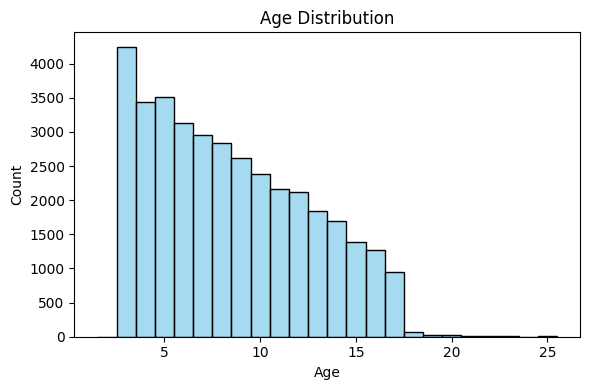

In [14]:
fig, ax = plt.subplots(figsize=(6,4))

ages = ages_all.squeeze().astype(int)   # ensure 1D numeric vector

sns.histplot(
    x=ages,
    bins=np.arange(1.5, 26.5, 1),  # bins centered on integers 2–25
    kde=False,
    color="skyblue",
    edgecolor="black",
    ax=ax
)

ax.set_xlabel("Age")
ax.set_ylabel("Count")
ax.set_title("Age Distribution")

plt.tight_layout()
plt.show()

C:\Users\B00804975\AppData\Local\Temp\ipykernel_23092\4035533728.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


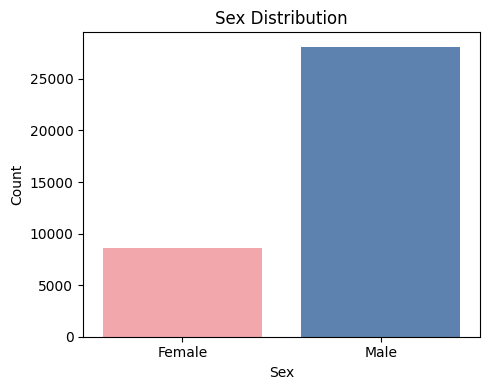

In [15]:
fig, ax = plt.subplots(figsize=(5,4))

sex = sex_all.squeeze().squeeze()   # 1D Series

sns.countplot(
    x=sex,
    order=["Female", "Male"],   # keeps consistent ordering
    palette=["#FF9AA2", "#4F81BD"],
    ax=ax
)

ax.set_xlabel("Sex")
ax.set_ylabel("Count")
ax.set_title("Sex Distribution")

plt.tight_layout()
plt.show()

In [16]:
import numpy as np
import pandas as pd
from itertools import combinations
from diptest import diptest
latent_df_avg.columns = [f"z{i+1}" for i in range(latent_df_avg.shape[1])]
def best_dip_projection_2d(X2, n_angles):
    best = {
        "dip": -np.inf,
        "pvalue": None,
        "angle": None,
        "direction": None,
        "projection": None,
    }

    angles = np.linspace(0, np.pi, n_angles, endpoint=False)

    for theta in angles:
        direction = np.array([np.cos(theta), np.sin(theta)])
        proj = X2 @ direction

        dip, pval = diptest(proj)

        if dip > best["dip"]:
            best["dip"] = dip
            best["pvalue"] = pval
            best["angle"] = theta
            best["direction"] = direction
            best["projection"] = proj.copy()

    return best


# -----------------------------
# Compute strongest result for each 2D pair
# -----------------------------
results = []

for c1, c2 in combinations(latent_df_avg.columns, 2):
    X2 = latent_df_avg[[c1, c2]].to_numpy()
    out = best_dip_projection_2d(X2, n_angles=360)

    results.append({
        "dim1": c1,
        "dim2": c2,
        "dip": out["dip"],
        "pvalue": out["pvalue"],
        "angle_rad": out["angle"],
        "dir_x": out["direction"][0],
        "dir_y": out["direction"][1],
        "projection": out["projection"],
    })

results_df = pd.DataFrame(results).sort_values("dip", ascending=False).reset_index(drop=True)

# Preview ranked results
print(results_df[["dim1", "dim2", "dip", "pvalue", "dir_x", "dir_y"]])

  dim1 dim2       dip    pvalue     dir_x     dir_y
0   z1   z3  0.002536  0.134088 -0.325568  0.945519
1   z2   z3  0.001600  0.848417  0.453990  0.891007
2   z2   z4  0.001598  0.849800  0.300706  0.953717
3   z1   z2  0.001584  0.860011  0.688355  0.725374
4   z1   z4  0.001517  0.907773 -0.608761  0.793353
5   z3   z4  0.001431  0.951637 -0.882948  0.469472


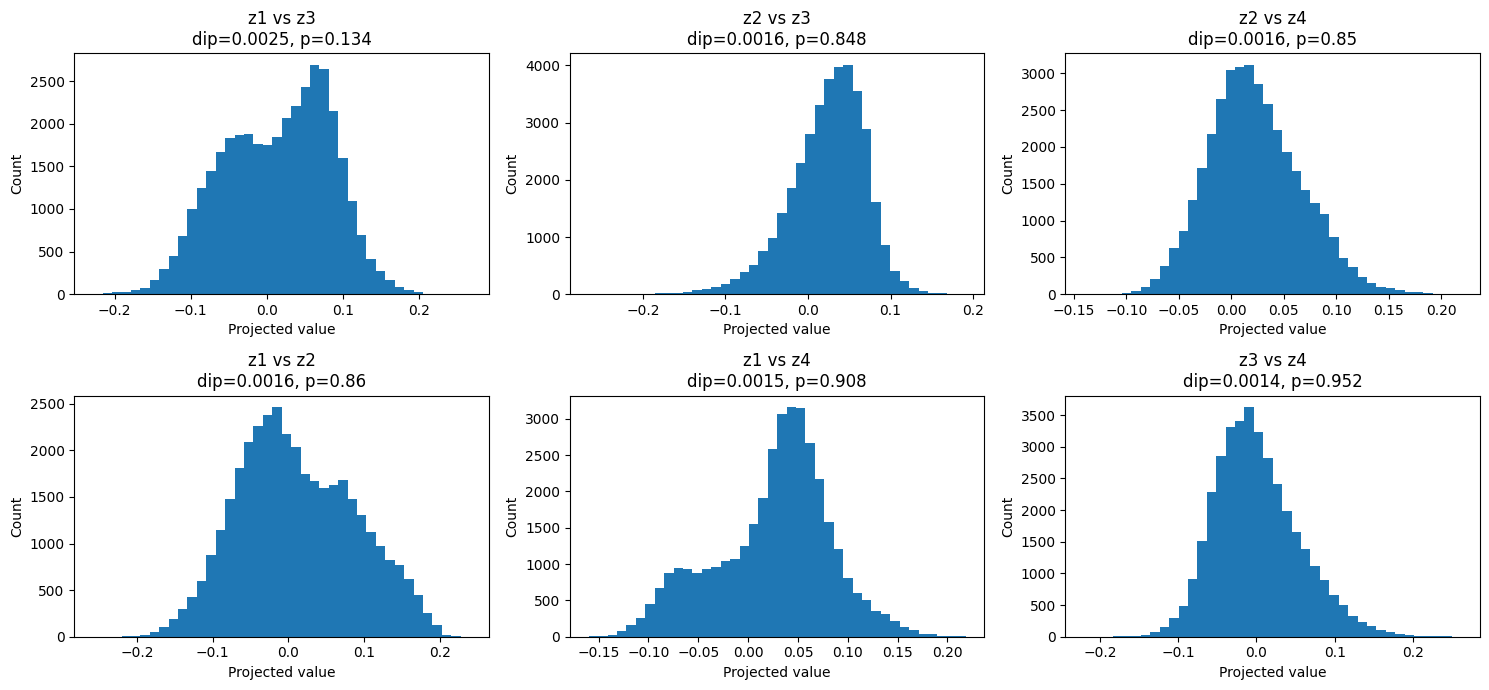

In [17]:
n_pairs = len(results_df)
ncols = 3
nrows = int(np.ceil(n_pairs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.5 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, results_df.iterrows()):
    proj = row["projection"]

    ax.hist(proj, bins=40)
    ax.set_title(
        f"{row['dim1']} vs {row['dim2']}\n"
        f"dip={row['dip']:.4f}, p={row['pvalue']:.3g}"
    )
    ax.set_xlabel("Projected value")
    ax.set_ylabel("Count")

# turn off any unused axes
for ax in axes[len(results_df):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

In [18]:
best_lookup = {
    (row["dim1"], row["dim2"]): np.array([row["dir_x"], row["dir_y"]])
    for _, row in results_df.iterrows()
}

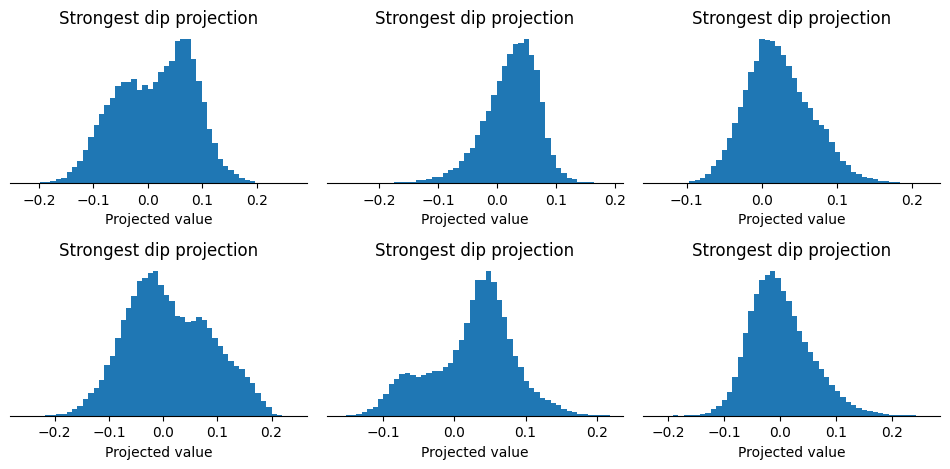

In [19]:
n_pairs = len(results_df)
ncols = 3
nrows = int(np.ceil(n_pairs / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, (_, row) in zip(axes, results_df.iterrows()):
    proj = row["projection"]

    ax.hist(proj, bins=50)
    ax.set_title("Strongest dip projection")
    ax.set_xlabel("Projected value")
    ax.set_yticks([])

    # remove extra spines
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)

# turn off unused axes
for ax in axes[len(results_df):]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("Strong_dip_all.png", dpi=600, bbox_inches="tight")
plt.show()

In [4]:
# Get sex values for validation set
sex_val = sex_all[idx_val]

# Combine age and sex
summary_data = pd.DataFrame({
    "Age": ages_all,
    "Sex": sex_all
})

# Age groups covering ages 2–25
bins = [2, 6, 10, 14, 18, 22, 26]

labels = [
    "2-5",
    "6-9",
    "10-13",
    "14-17",
    "18-21",
    "22-25"
]

summary_data["Age group"] = pd.cut(
    summary_data["Age"],
    bins=bins,
    labels=labels,
    right=False,
    include_lowest=True
)

# Create table
age_table = (
    summary_data
    .groupby("Age group", observed=False)
    .agg(
        Amount_of_people=("Age", "count"),
        Number_of_M=("Sex", lambda x: (x == "Male").sum()),
        Number_of_F=("Sex", lambda x: (x == "Female").sum())
    )
    .reset_index()
)

# Rename columns
age_table.columns = [
    "Age group",
    "Amount of people",
    "Number of Male",
    "Number of Female"
]

print(age_table)

  Age group  Amount of people  Number of Male  Number of Female
0       2-5             11200            8545              2655
1       6-9             11526            8959              2567
2     10-13              8514            6566              1948
3     14-17              5313            3925              1388
4     18-21               119              94                25
5     22-25                28              23                 5
